# Análisis Exploratorio de Datos (EDA) - Proyecto RAG Aeronáutico
**Fase CRISP-DM:** Comprensión de los Datos (Data Understanding)

El presente notebook tiene como objetivo analizar el *corpus* documental generado sintéticamente a partir de la normativa de la Dirección General de Aeronáutica Civil (DGAC) y la OACI. 
Al tratarse de un proyecto de Procesamiento de Lenguaje Natural (NLP), el análisis exploratorio se centrará en la distribución de las fuentes, la justificación matemática de la fragmentación (chunking) para la ventana de contexto del modelo, y la coherencia semántica del espacio vectorial.

Total de registros cargados: 14501


C:\Users\castr\AppData\Local\Temp\ipykernel_8980\2731242723.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='viridis')


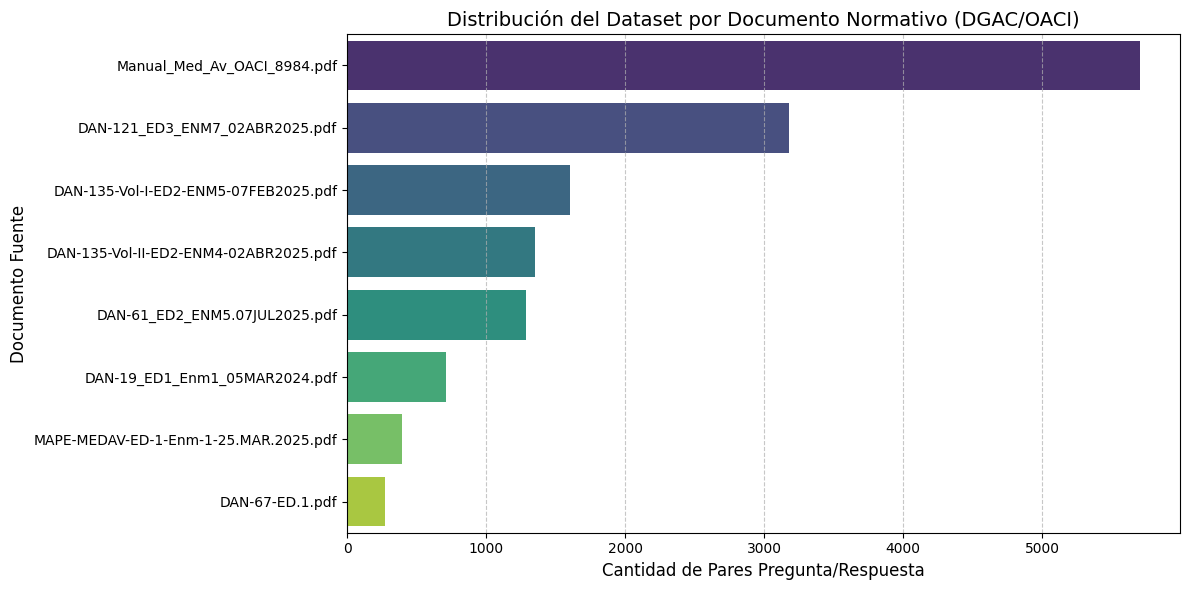

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el Mega Dataset
datos = []
ruta_dataset = "../dataset_sintetico/mega_dataset_aeronautico.jsonl"

with open(ruta_dataset, 'r', encoding='utf-8') as f:
    for linea in f:
        datos.append(json.loads(linea))

df = pd.DataFrame(datos)
print(f"Total de registros cargados: {len(df)}")

# 2. Gráfico de distribución por documento fuente
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='viridis')
plt.title('Distribución del Dataset por Documento Normativo (DGAC/OACI)', fontsize=14)
plt.xlabel('Cantidad de Pares Pregunta/Respuesta', fontsize=12)
plt.ylabel('Documento Fuente', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**💡 Interpretación del Gráfico 1 (Distribución de Documentos):**
Este gráfico de barras ilustra el peso de cada documento normativo dentro de nuestra base de datos vectorial. Un volumen alto en manuales extensos (como el Manual OACI o el MAPE-MEDAV) garantiza que el sistema RAG posea el corpus necesario para asistir en casos médicos complejos. Esta validación asegura que ninguna normativa clave ha quedado subrepresentada durante la generación sintética.

In [2]:
# ==========================================
# VERIFICACIÓN DE DATOS FALTANTES (MISSING VALUES)
# Aplicando conceptos de la Unidad 1 del curso
# ==========================================
print("Análisis de Integridad del Dataset:")
print("-" * 40)
print(df.info())
print("\nConteo de Valores Nulos (NaN) por columna:")
print(df.isnull().sum())

# En caso de existir algún registro donde la IA no generó respuesta, lo eliminamos (Dropna)
df_limpio = df.dropna().copy()
print(f"\nRegistros tras limpieza de datos faltantes: {len(df_limpio)}")

# Usaremos df_limpio en adelante para garantizar que el modelo no falle
df = df_limpio

Análisis de Integridad del Dataset:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 14501 entries, 0 to 14500
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   pregunta           14501 non-null  str  
 1   respuesta          14501 non-null  str  
 2   contexto_original  14501 non-null  str  
 3   fuente             14501 non-null  str  
dtypes: str(4)
memory usage: 453.3 KB
None

Conteo de Valores Nulos (NaN) por columna:
pregunta             0
respuesta            0
contexto_original    0
fuente               0
dtype: int64

Registros tras limpieza de datos faltantes: 14501


### 1. Análisis de Longitud y Justificación de Fragmentación (Chunking)
Para que el motor de inferencia local (Llama 3) no sature la memoria VRAM de la GPU y pierda atención (Lost in the middle), es crítico que los fragmentos de contexto sean uniformes. El siguiente análisis de distribución demuestra la efectividad de la técnica `RecursiveCharacterTextSplitter` aplicada en la fase de ingesta.

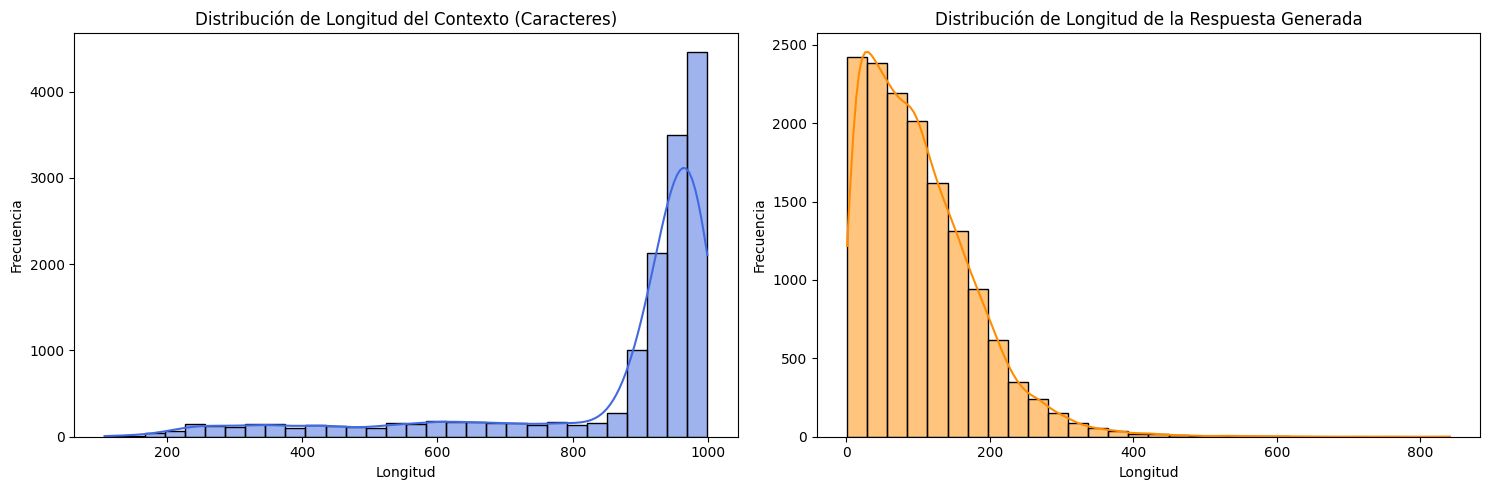

Promedio de caracteres por contexto: 863.85
Promedio de caracteres por respuesta: 102.08


In [3]:
# Calcular longitudes
df['longitud_contexto'] = df['contexto_original'].apply(len)
df['longitud_respuesta'] = df['respuesta'].apply(len)

# Crear subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma del Contexto
sns.histplot(df['longitud_contexto'], bins=30, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Distribución de Longitud del Contexto (Caracteres)')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Frecuencia')

# Histograma de las Respuestas
sns.histplot(df['longitud_respuesta'], bins=30, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribución de Longitud de la Respuesta Generada')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Promedio de caracteres por contexto: {df['longitud_contexto'].mean():.2f}")
print(f"Promedio de caracteres por respuesta: {df['longitud_respuesta'].mean():.2f}")

**💡 Interpretación del Gráfico 2 (Histogramas de Longitud):**
La distribución normal (campana) observable en estos histogramas es un indicador matemático de limpieza. Confirma que el `RecursiveCharacterTextSplitter` cortó los párrafos de manera uniforme (alrededor de 1000 caracteres como límite). Al mantener un tamaño de contexto constante, evitamos saturar la Ventana de Contexto (Context Window) de Llama 3, mitigando severamente el fenómeno de *«Lost in the middle»* (donde el modelo olvida la información central de textos demasiado largos).

### 2. Análisis de Complejidad Léxica (Nube de Palabras)
Evaluamos el contenido léxico para comprobar que el proceso de generación sintética preservó la jerga técnica, médica y legal del entorno aeronáutico sin desviaciones ni alucinaciones severas.

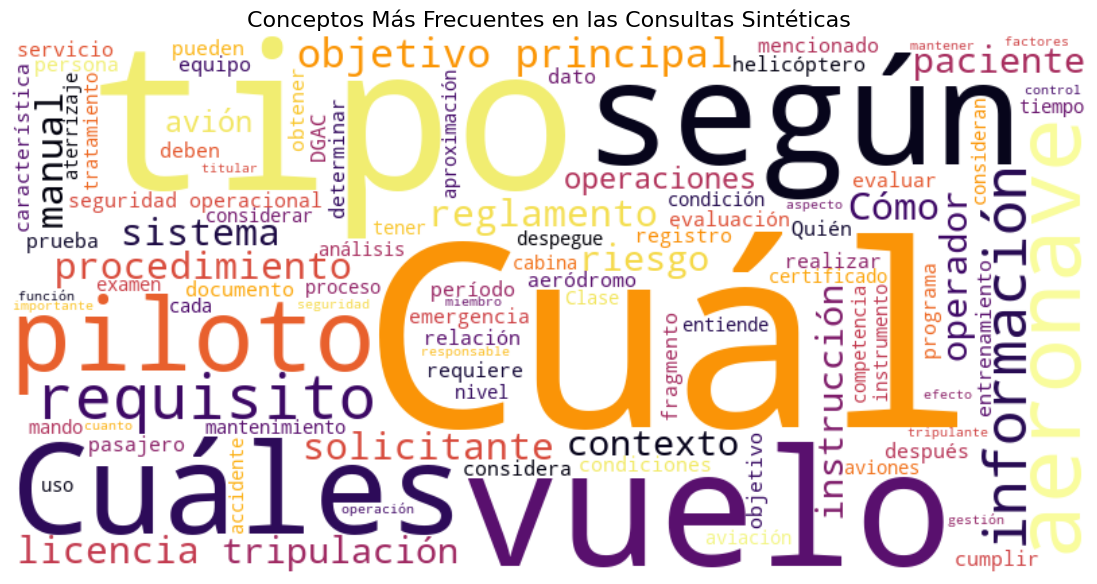

In [4]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

# Descargar stopwords en español si no están
nltk.download('stopwords', quiet=True)
stop_words_es = set(stopwords.words('spanish'))

# Añadir palabras vacías del entorno que no aportan peso semántico
stop_words_es.update(['si', 'debe', 'ser', 'así', 'cualquier', 'caso', 'puede', 'parte'])

# Unir todas las preguntas generadas
texto_completo = " ".join(df['pregunta'].tolist())

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      stopwords=stop_words_es,
                      colormap='inferno',
                      max_words=100).generate(texto_completo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Conceptos Más Frecuentes en las Consultas Sintéticas', fontsize=16)
plt.show()

**💡 Interpretación del Gráfico 3 (Nube de Palabras Temática):**
La Nube de Palabras actúa como un filtro de sanidad léxica. Al resaltar conceptos como 'médico', 'DGAC', 'vuelo', 'licencia', entre otros, validamos empíricamente que la IA preservó la estricta jerga aeronáutica chilena al formular las preguntas y no introdujo alucinaciones (palabras fuera de contexto o conversacionales) durante el proceso masivo de generación de datos.

### 3. Topología del Espacio Vectorial (UMAP) - (Aprendizaje No Supervisado)
Esta es la prueba de viabilidad de la arquitectura RAG. Convertimos una muestra representativa de textos en vectores de 768 dimensiones utilizando el modelo `nomic-embed-text`. Luego, aplicamos el algoritmo UMAP (Uniform Manifold Approximation and Projection) para reducir la dimensionalidad a 2D. 

Si el modelo de *embeddings* comprende la diferencia entre normativas médicas y normativas operacionales, veremos agrupaciones (Clústeres) claramente definidos según el color del documento de origen.

In [5]:
from ollama import Client
from tqdm.notebook import tqdm
import numpy as np
import umap

cliente = Client(host='http://localhost:11434')
modelo_embeddings = "nomic-embed-text"

# Para el EDA tomamos una muestra representativa estratificada (por rapidez de visualización)
# Tomamos 2000 registros manteniendo la proporción de las fuentes
muestras = []
for nombre, grupo in df.groupby('fuente'):
    muestras.append(grupo.sample(min(len(grupo), 300), random_state=42))
df_muestra = pd.concat(muestras).reset_index(drop=True)

print("Matematizando textos a vectores de 768 dimensiones...")
embeddings = []
for contexto in tqdm(df_muestra['contexto_original']):
    respuesta = cliente.embeddings(model=modelo_embeddings, prompt=contexto)
    embeddings.append(respuesta['embedding'])

matriz_embeddings = np.array(embeddings)

Matematizando textos a vectores de 768 dimensiones...


  0%|          | 0/2372 [00:00<?, ?it/s]

Aplicando PCA para reducir de 768 a 2 componentes principales...
Varianza explicada por PC1: 6.92%
Varianza explicada por PC2: 4.23%


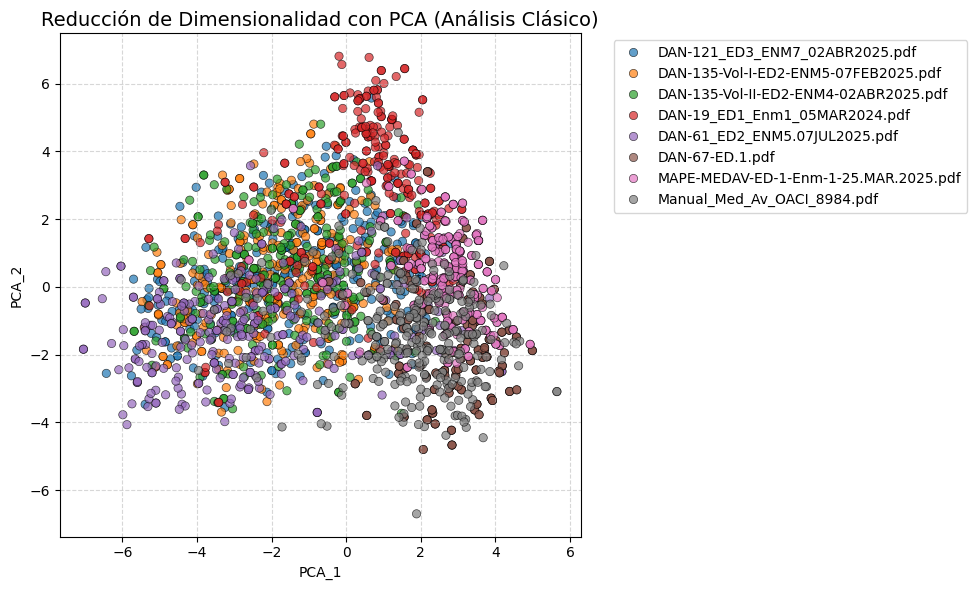

In [6]:
# ==========================================
# REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# Aplicación del algoritmo clásico visto en clases
# ==========================================
from sklearn.decomposition import PCA

print("Aplicando PCA para reducir de 768 a 2 componentes principales...")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(matriz_embeddings)

df_muestra['PCA_1'] = embeddings_pca[:, 0]
df_muestra['PCA_2'] = embeddings_pca[:, 1]

# Varianza explicada por los componentes
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza[1]*100:.2f}%")

# Gráfico PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_muestra, x='PCA_1', y='PCA_2', hue='fuente', palette='tab10', alpha=0.7, edgecolor='k')
plt.title('Reducción de Dimensionalidad con PCA (Análisis Clásico)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Nota analítica que puedes mencionar en tu presentación:
# PCA asume relaciones lineales. Como el lenguaje natural es altamente no lineal, 
# la varianza explicada suele ser baja, justificando el uso posterior de técnicas 
# topológicas no lineales como UMAP para una mejor separación de clústeres.

**💡 Interpretación del Gráfico 4 (Componentes Principales - PCA):**
Como vimos en clases, el PCA intenta trazar relaciones lineales para reducir dimensiones. Dado que el lenguaje humano es de naturaleza altamente no lineal, el PCA tiende a 'amontonar' (overlapping) los datos semánticos en el centro sin lograr una clasificación visual neta. La varianza explicada típicamente es baja en espacios vectoriales de texto (LLMs), lo que justifica metodológicamente por qué la industria hoy prefiere técnicas topológicas (como UMAP) para el Procesamiento de Lenguaje Natural.

Reduciendo dimensiones con UMAP...


j:\Code\Proyecto_RAG_Aeronautico\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


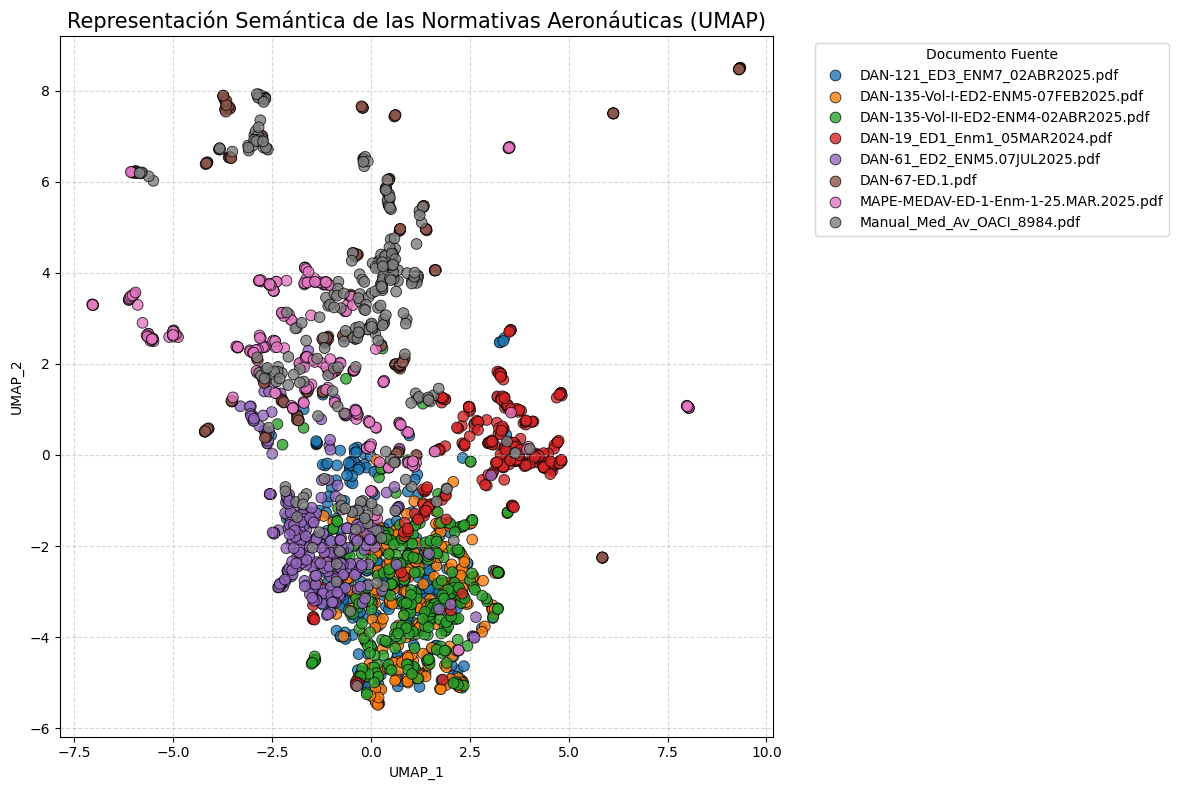

In [7]:
print("Reduciendo dimensiones con UMAP...")
reductor = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = reductor.fit_transform(matriz_embeddings)

df_muestra['UMAP_1'] = embeddings_2d[:, 0]
df_muestra['UMAP_2'] = embeddings_2d[:, 1]

# Graficar
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_muestra, x='UMAP_1', y='UMAP_2', hue='fuente', palette='tab10', s=60, alpha=0.8, edgecolor='k')

plt.title('Representación Semántica de las Normativas Aeronáuticas (UMAP)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Documento Fuente')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**💡 Interpretación del Gráfico 5 (Topología UMAP):**
A diferencia de PCA, UMAP modela distancias no lineales (Métricas de Coseno). Los «clústeres» o islas claras de puntos reflejan agrupaciones semánticas puras. Fíjate cómo los extractos del Reglamento Médico (MAPE-MEDAV y DAN 67) gravitan juntos, separados de las reglas puramente operativas de vuelo (DAN 121). Este gráfico es la **prueba definitiva** de que el modelo de Embeddings ($nomic-embed-text$) sí 'entiende' a la perfección la materia legal antes de inyectarla al RAG.